# Regresion Lineal Simple - Colesterol y habitos de salud

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Simple

---

### Objetivo

Predecir el nivel de colesterol de un paciente a partir de su IMC (indice de masa corporal) usando regresion lineal simple. Con solo 50 registros.


### Contexto de negocio

**El cliente:** un centro de salud que quiere identificar pacientes con colesterol elevado de forma rapida.

**El problema:** las analiticas completas tardan dias. Si el IMC (medicion instantanea) pudiera predecir el colesterol, se podrian priorizar citas y prevenir riesgos.

**La pregunta:** existe una relacion lineal entre IMC y colesterol lo suficientemente fuerte para usarla como screening?

## 1️. Setup: librerías y configuración visual

In [ ]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Modelado estadístico (interpretación)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine Learning (predicción)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tests estadísticos
from scipy import stats

# Configuración general
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(42)  # Reproducibilidad — siempre fijar la semilla

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis (1 por gráfico) / serie única en scatter y líneas
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto en un mismo gráfico
INK           = '#111111'
MUTED         = '#707070'

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [2]:
data = pd.read_csv("patient_health.csv")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 50 | Columnas: 11


,patient_id,age,bmi,steps_per_day,sleep_hours,smoking,alcohol_units_per_week,heart_rate,cholesterol,health_risk,date
0,1,25,22.5000,9000,7,No,2,72,180,Low,2024-01-01
1,2,45,28.1000,4000,6,Yes,8,88,240,High,2024-01-02
2,3,30,24.0000,7000,7,No,3,75,190,Low,2024-01-03
3,4,50,31.2000,3000,5,Yes,10,92,260,High,2024-01-04
4,5,38,27.5000,5000,6,No,5,80,220,Medium,2024-01-05


In [3]:
data['smoking_num'] = data['smoking'].map({'No': 0, 'Yes': 1})

## 3. EDA

In [4]:
# Estadística descriptiva

# Seleccionamos solo las columnas numericas relevantes
cols_num = ["age", "bmi", "steps_per_day", "sleep_hours", "smoking_num",
            "alcohol_units_per_week", "heart_rate", "cholesterol"]
data[cols_num].describe().round(2)

,age,bmi,steps_per_day,sleep_hours,smoking_num,alcohol_units_per_week,heart_rate,cholesterol
count,50.0000,50.0000,50.0000,50.0000,50.0000,50.0000,50.0000,50.0000
mean,41.9600,26.9100,"5,626.0000",6.2800,0.4000,6.1400,81.6800,220.8400
std,11.6400,3.4500,"2,772.5200",1.0900,0.4900,3.9600,10.0800,38.4200
min,25.0000,21.5000,"1,200.0000",5.0000,0.0000,1.0000,67.0000,165.0000
25%,31.2500,24.0000,"3,000.0000",5.0000,0.0000,3.0000,74.0000,190.0000
50%,41.0000,26.9000,"5,600.0000",6.0000,0.0000,5.0000,79.5000,215.0000
75%,51.7500,29.8800,"8,000.0000",7.0000,1.0000,10.0000,91.0000,253.7500
max,63.0000,33.0000,"10,000.0000",8.0000,1.0000,14.0000,100.0000,300.0000


In [5]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
patient_id,int64,0,0.0000,50
age,int64,0,0.0000,38
bmi,float64,0,0.0000,47
steps_per_day,int64,0,0.0000,36
sleep_hours,int64,0,0.0000,4
smoking,object,0,0.0000,2
alcohol_units_per_week,int64,0,0.0000,14
heart_rate,int64,0,0.0000,28
cholesterol,int64,0,0.0000,29
health_risk,object,0,0.0000,3


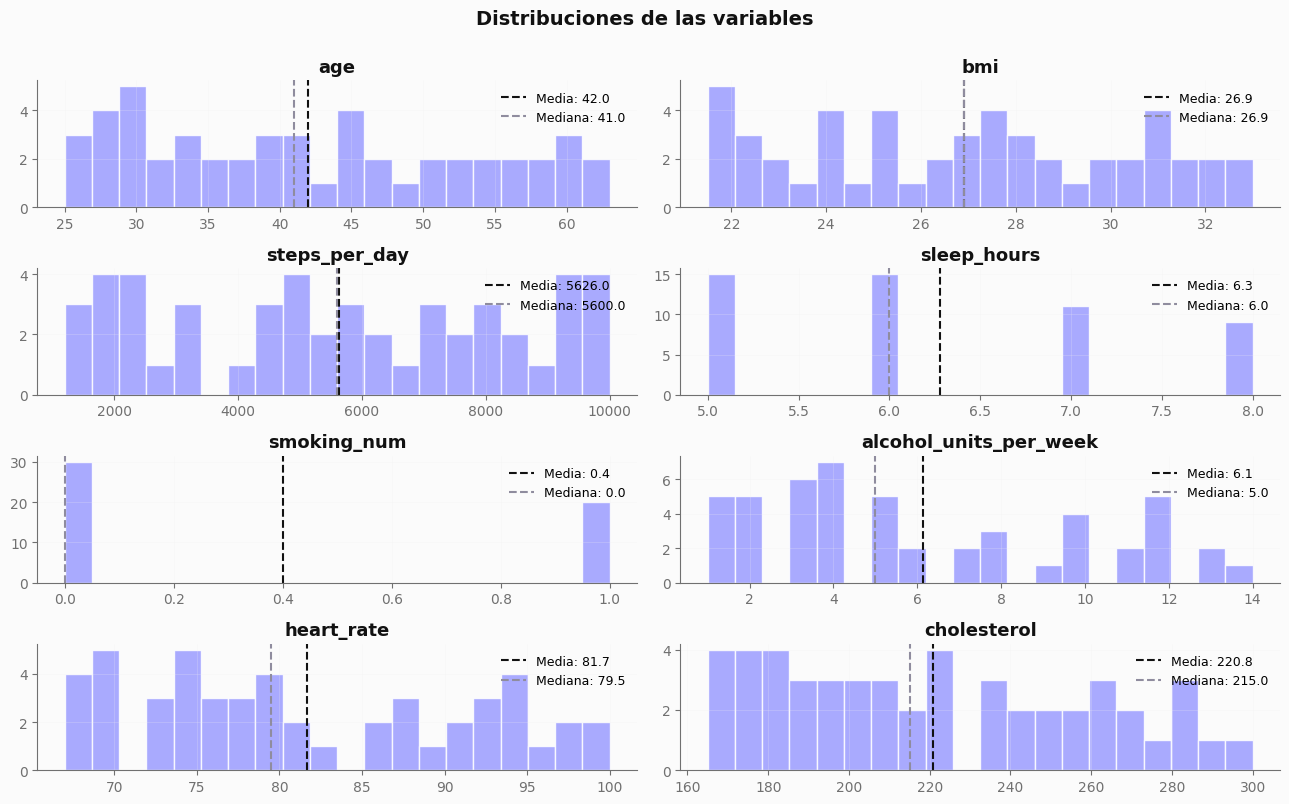

In [6]:
# Distribuciones de cada variable

fig, axes = plt.subplots(4, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ["age", "bmi", "steps_per_day", "sleep_hours", 'smoking_num', "alcohol_units_per_week", "heart_rate", "cholesterol"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE_LIGHT, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=INK, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=NEUTRAL_LINE, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

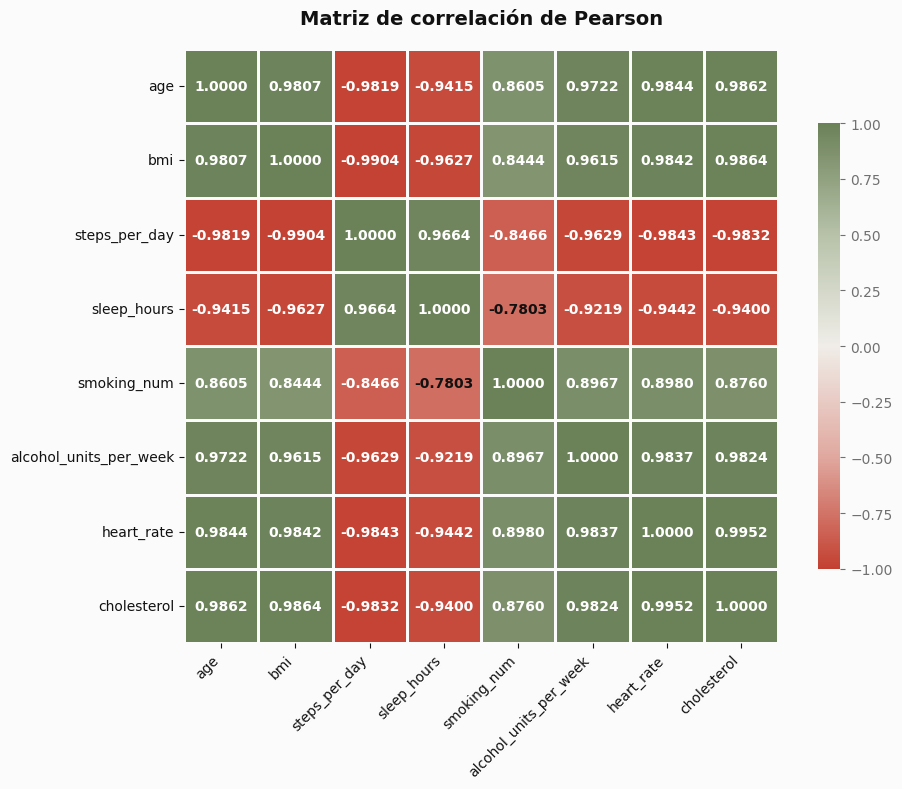

In [7]:
# Matriz de correlación

corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=DIVERGING_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor=BACKGROUND,
    cbar_kws={"shrink": 0.75},
    annot_kws={
        "size": 10,
        "weight": "bold",
    },
)
color_annotations(ax, corr.values, threshold=0.8)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Columna del target (Colesterol)

- `heart_rate`: 0.9952 → correlación muy fuerte y positiva. Es la variable con mayor asociación lineal con el colesterol.
- `bmi`: 0.9864 → correlación muy fuerte y positiva.
- `age`: 0.9862 → correlación muy fuerte y positiva.
- `alcohol_units_per_week`: 0.9824 → correlación muy fuerte y positiva.
- `smoking_num`: 0.8760 → correlación muy fuerte y positiva.
- `steps_per_day`: -0.9832 → correlación muy fuerte y negativa. Un mayor número de pasos diarios se asocia con menores niveles de colesterol.
- `sleep_hours`: -0.9400 → correlación muy fuerte y negativa. Dormir más horas se relaciona con menores niveles de colesterol.

#### Entre variables predictoras
- `age ↔ bmi`: 0.9807 → correlación muy fuerte y positiva.
- `age ↔ heart_rate`: 0.9844 → correlación muy fuerte y positiva.
- `bmi ↔ heart_rate`: 0.9842 → correlación muy fuerte y positiva.
- `steps_per_day ↔ bmi`: -0.9904 → correlación muy fuerte y negativa.
- `steps_per_day ↔ heart_rate`: -0.9843 → correlación muy fuerte y negativa.
- `sleep_hours ↔ steps_per_day`: 0.9664 → correlación muy fuerte y positiva.

Se observa una elevada correlación entre las variables predictoras, lo que sugiere la presencia de multicolinealidad. Esto indica que varias variables contienen información muy similar y podrían afectar a la estabilidad e interpretación de un modelo de regresión lineal múltiple.

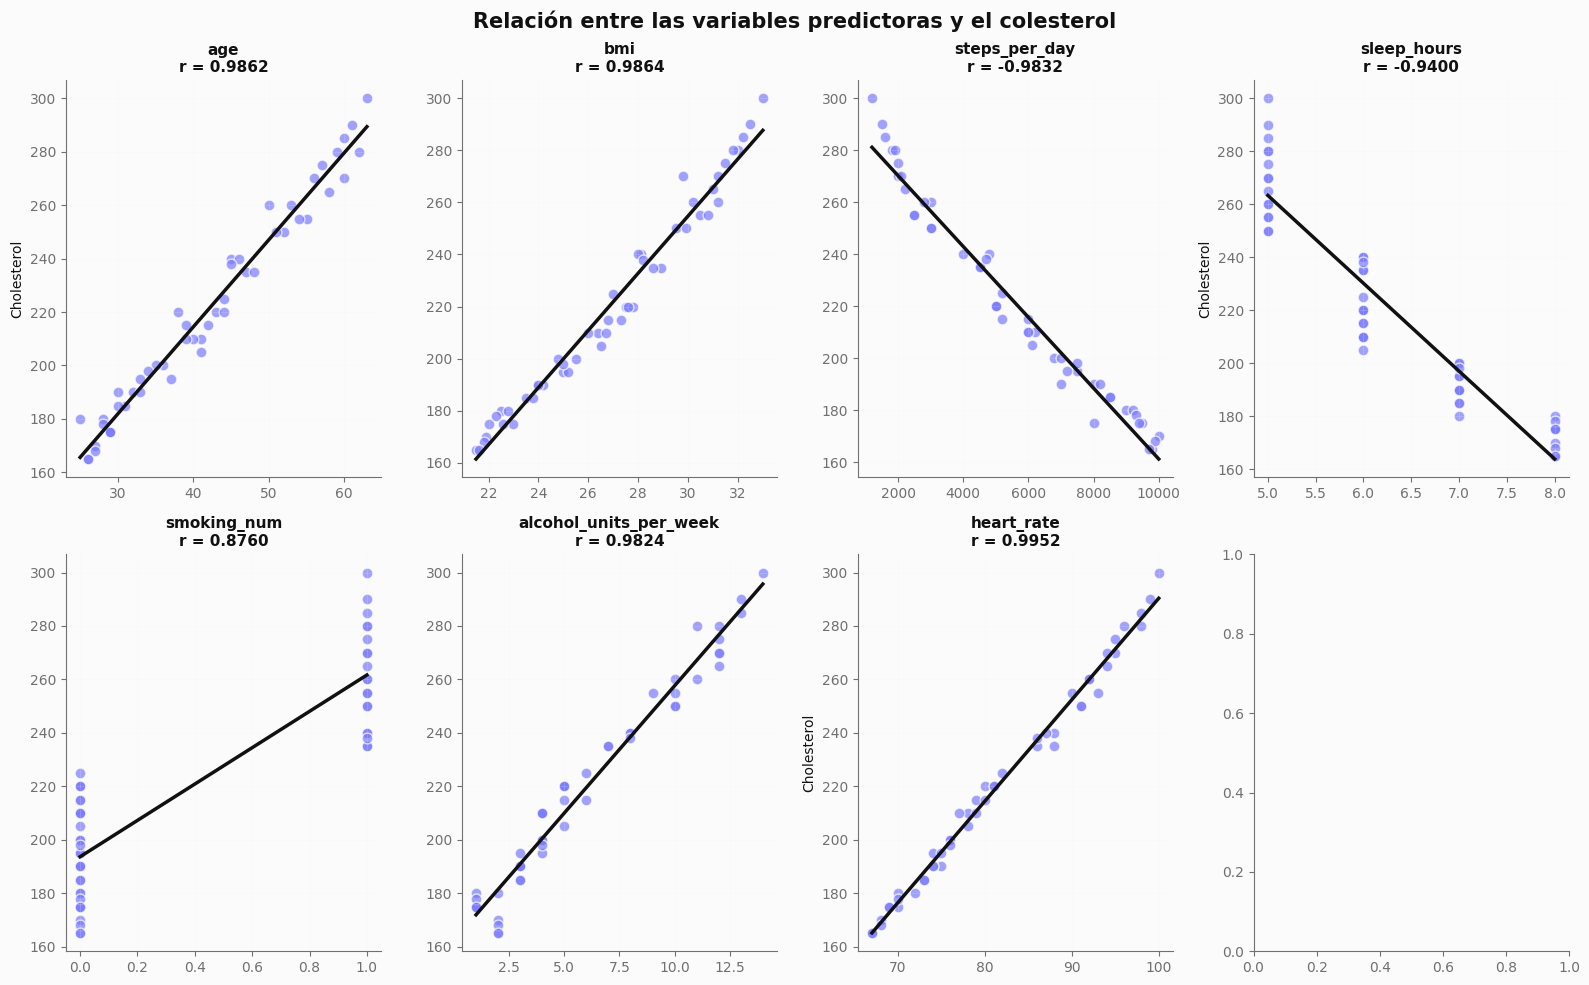

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(cols_num[:-1]):

    sns.regplot(
        data=data,
        x=col,
        y="cholesterol",
        ax=axes[i],
        scatter_kws={
            "color": PURPLE,
            "edgecolor": "white",
            "s": 60,
            "alpha": 0.70,
        },
        line_kws={
            "color": INK,
            "linewidth": 2.5,
        },
        ci=None,
    )

    r = data[col].corr(data["cholesterol"])

    axes[i].set_title(
        f"{col}\nr = {r:.4f}",
        fontsize=11,
        fontweight="bold",
        color=INK,
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Cholesterol" if i % 3 == 0 else "")

    axes[i].grid(alpha=0.25)

plt.suptitle(
    "Relación entre las variables predictoras y el colesterol",
    fontsize=15,
    fontweight="bold",
    color=INK,
)

plt.tight_layout()
plt.show()

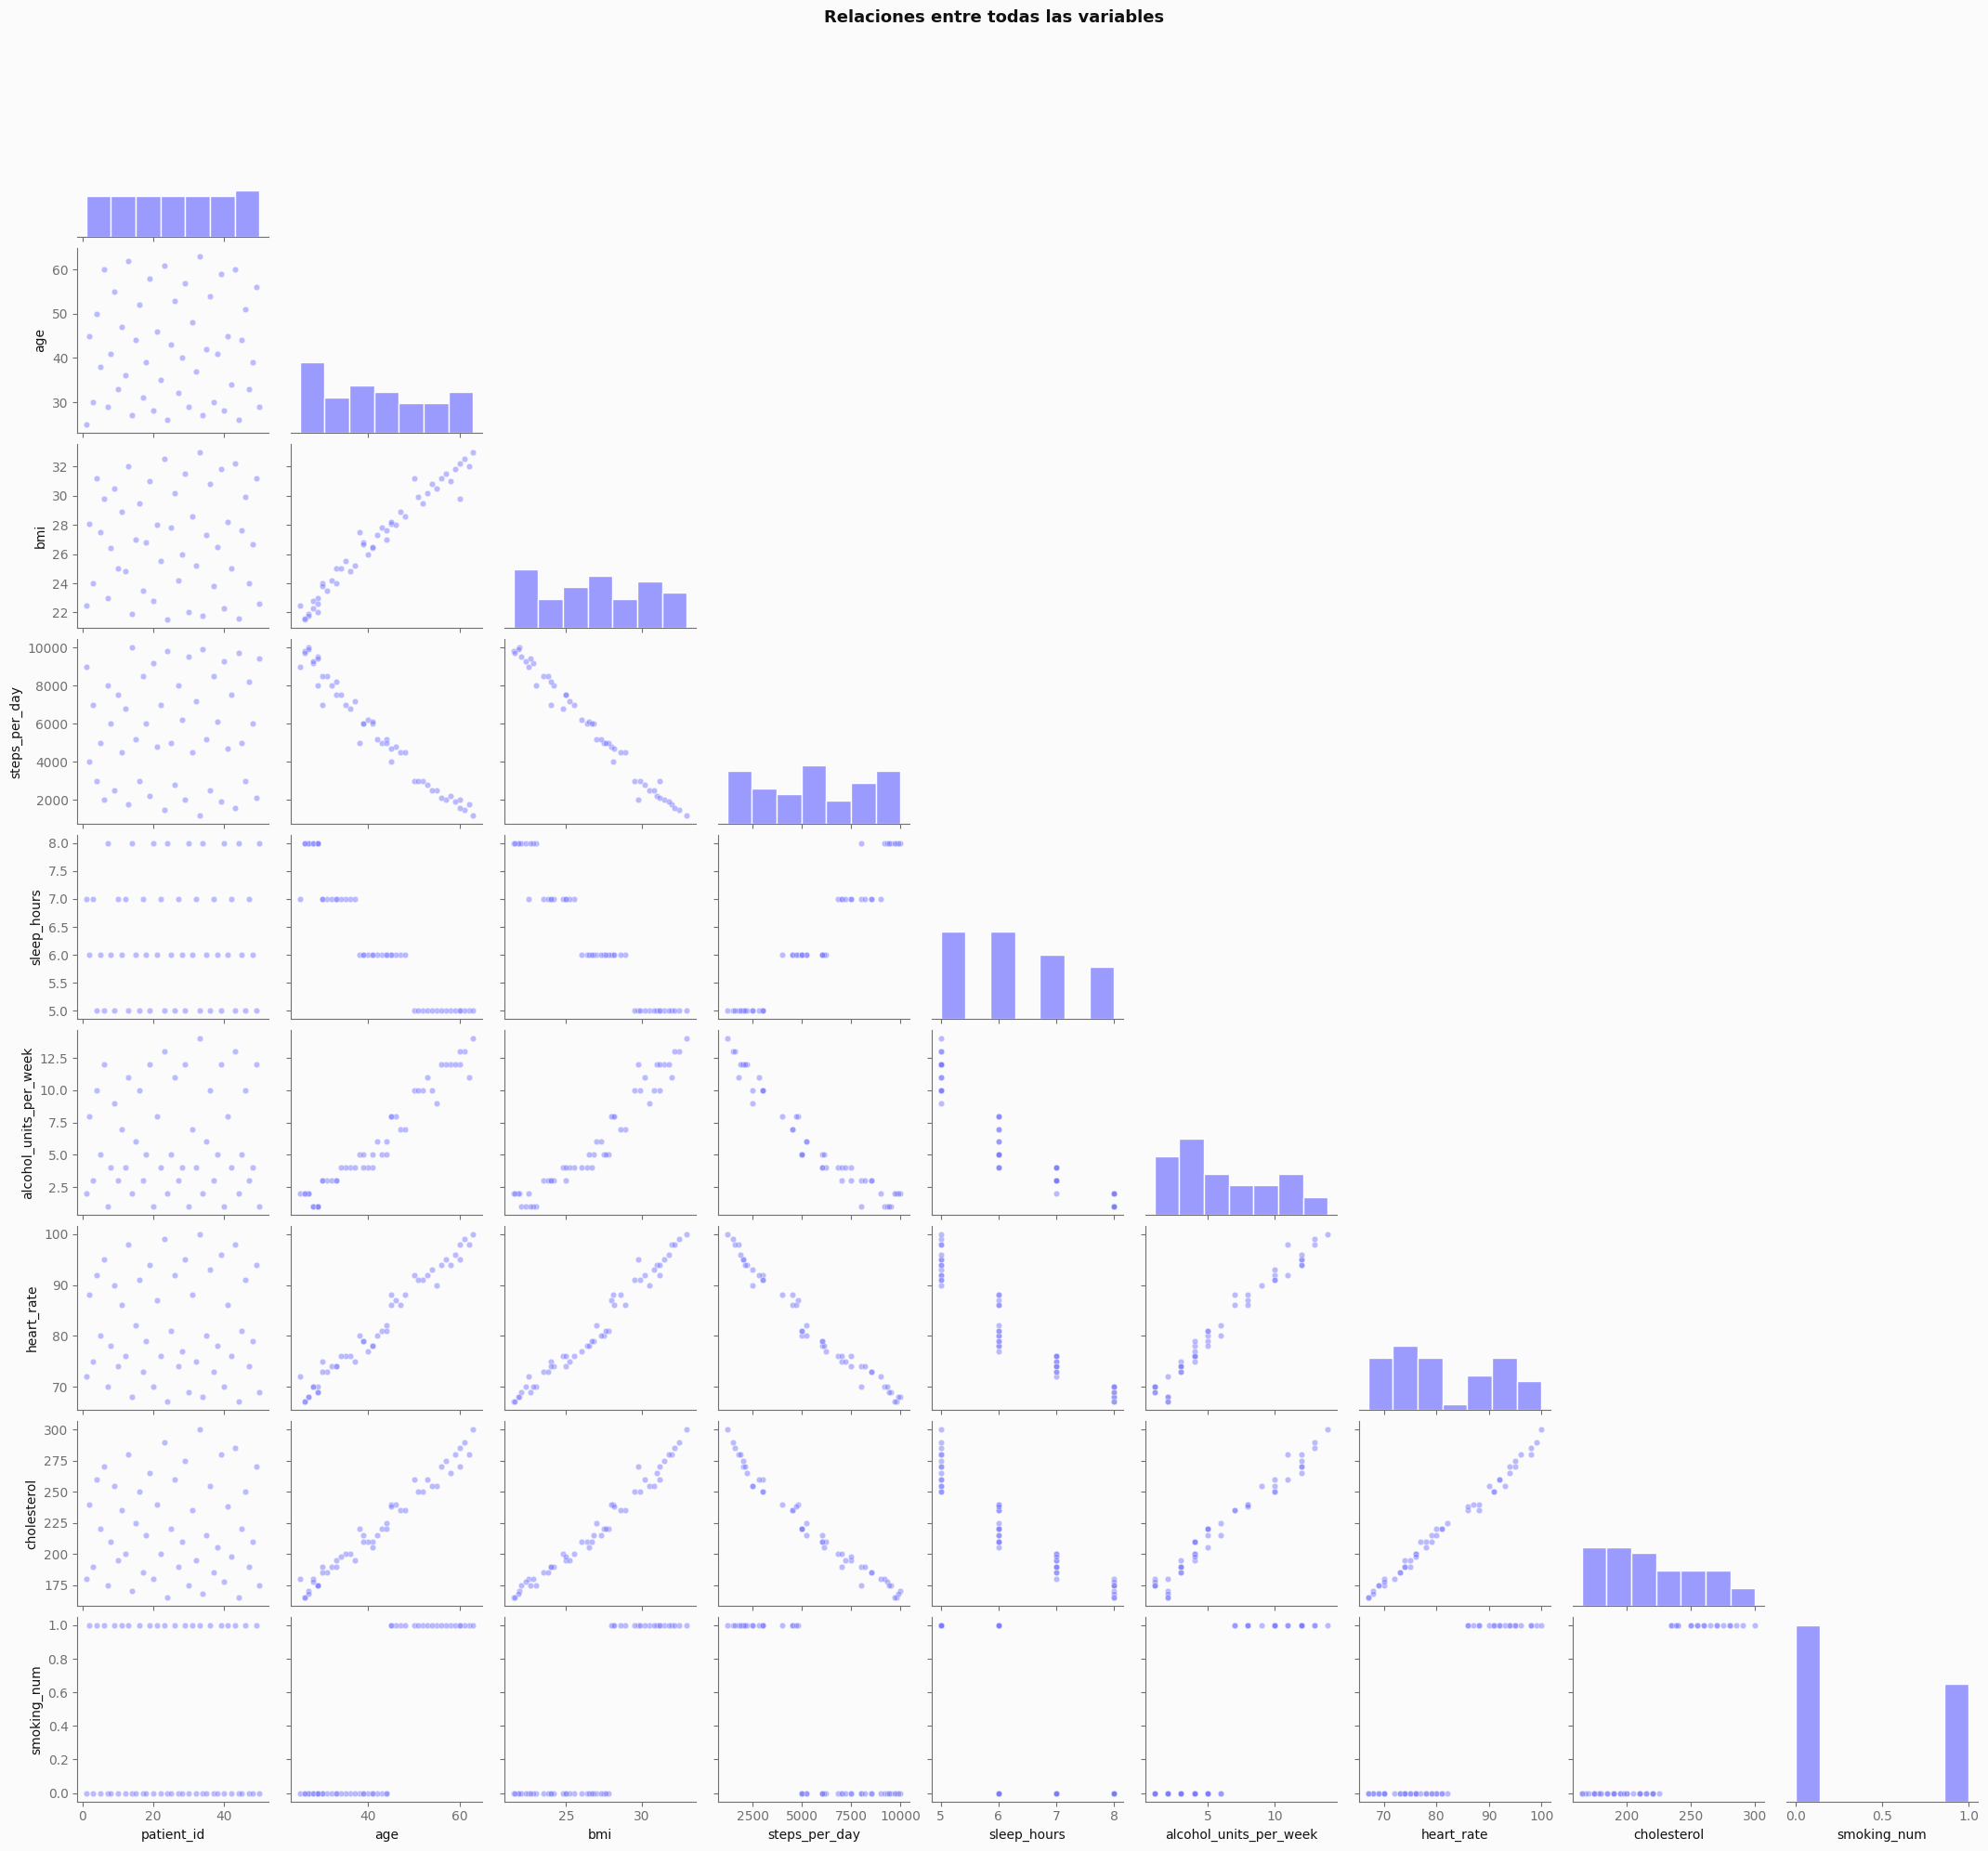

In [9]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data, height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Selección del modelo

### Modelo 1 - Regresión Lineal Simple

In [10]:
# 1. Definimos X (predictoras) e y (target)
X = data[['bmi']]
y  = data['cholesterol']

# 2. PASO IMPRESCINDIBLE: añadir la constante (el intercepto)
#    statsmodels NO lo añade automáticamente. Si te lo olvidas, el modelo asume
#    que la recta pasa por el origen, lo cual casi nunca tiene sentido.
X_const = sm.add_constant(X)

# 3. Ajustamos el modelo (OLS = Ordinary Least Squares = Mínimos Cuadrados Ordinarios)
modelo_1 = sm.OLS(y, X_const).fit()

# 4. Imprimimos el resumen completo
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:            cholesterol   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1728.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           2.68e-39
Time:                        11:23:53   Log-Likelihood:                -162.60
No. Observations:                  50   AIC:                             329.2
Df Residuals:                      48   BIC:                             333.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -74.5245      7.162    -10.405      0.0

In [11]:
# Extraemos los valores clave del modelo
print(' RESUMEN DEL MODELO 1 (Regresión Simple)')
print('═' * 60)
print(f'  R²                : {modelo_1.rsquared:.6f}')
print(f'  R² ajustado       : {modelo_1.rsquared_adj:.6f}')
print(f'  F-statistic       : {modelo_1.fvalue:.2f}')
print(f'  Prob (F)          : {modelo_1.f_pvalue:.4e}')
print(f'  AIC               : {modelo_1.aic:.2f}')
print(f'  Nº observaciones  : {int(modelo_1.nobs)}')
print()

# Tabla de coeficientes con interpretación
coefs_1 = pd.DataFrame({
    'Coeficiente': modelo_1.params.round(4),
    'Error típico': modelo_1.bse.round(4),
    't': modelo_1.tvalues.round(4),
    'p-valor': modelo_1.pvalues.apply(lambda x: f'{x:.4e}'),
    'Significativo': modelo_1.pvalues.apply(lambda x: 'Sí' if x < 0.05 else 'No')
})
print('COEFICIENTES:')
print(coefs_1)

# Ecuación final del modelo
b0 = modelo_1.params['const']
b1 = modelo_1.params['bmi']
print(f'\n ECUACIÓN: Colesterol = {b0:.2f} + {b1:.2f} × bmi')

 RESUMEN DEL MODELO 1 (Regresión Simple)
════════════════════════════════════════════════════════════
  R²                : 0.972974
  R² ajustado       : 0.972411
  F-statistic       : 1728.08
  Prob (F)          : 2.6759e-39
  AIC               : 329.20
  Nº observaciones  : 50

COEFICIENTES:
       Coeficiente  Error típico        t     p-valor Significativo
const     -74.5245        7.1623 -10.4051  6.7921e-14            Sí
bmi        10.9760        0.2640  41.5702  2.6759e-39            Sí

 ECUACIÓN: Colesterol = -74.52 + 10.98 × bmi


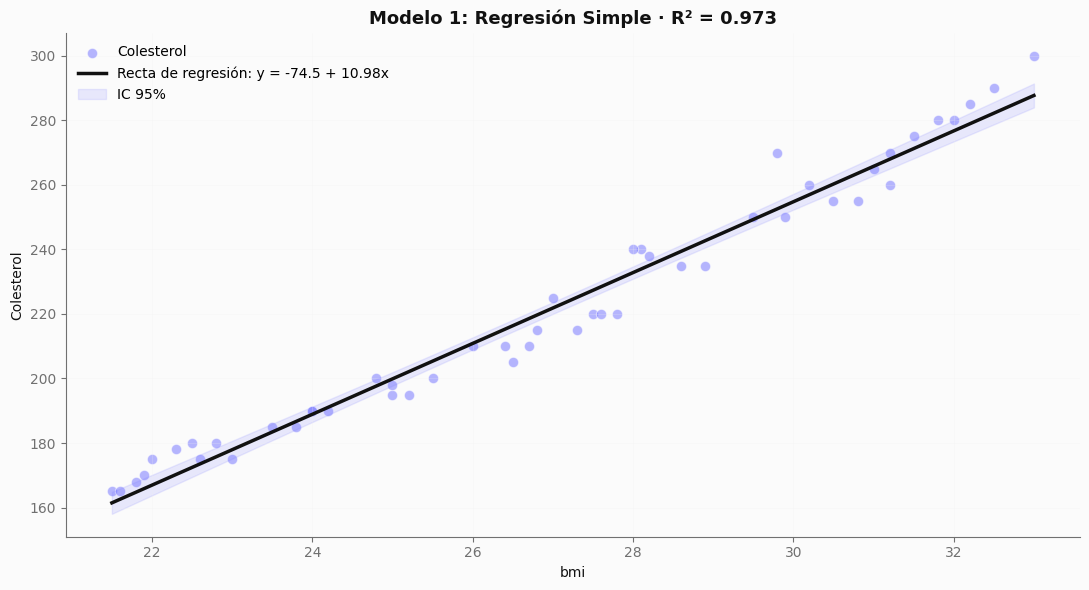

In [12]:
# Visualización del modelo
fig, ax = plt.subplots(figsize=(11, 6))

# Puntos reales
ax.scatter(data['bmi'], data['cholesterol'],
           color=PURPLE, alpha=0.55, s=55, edgecolor='white', linewidth=0.8, label='Colesterol')

# Línea de regresión
x_line = np.linspace(data['bmi'].min(), data['bmi'].max(), 100)
y_line = b0 + b1 * x_line
ax.plot(x_line, y_line, color=INK, linewidth=2.5, label=f'Recta de regresión: y = {b0:.1f} + {b1:.2f}x')

# Banda de confianza al 95%
predictions = modelo_1.get_prediction(sm.add_constant(pd.DataFrame({'bmi': x_line})))
ci = predictions.conf_int(alpha=0.05)
ax.fill_between(x_line, ci[:, 0], ci[:, 1], color=PURPLE, alpha=0.15, label='IC 95%')

ax.set_xlabel('bmi')
ax.set_ylabel('Colesterol')
ax.set_title(f'Modelo 1: Regresión Simple · R² = {modelo_1.rsquared:.3f}', fontsize=13, fontweight='bold', color=INK)
ax.legend(loc='upper left', frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusión:

- Con solo la variable BMI el modelo es capaz de explicar aproximadamente el 97 % de la variabilidad del colesterol (R² = 0.973), lo que indica un ajuste excelente.
- Por cada incremento de 1 unidad en el BMI, el colesterol aumenta, en promedio, 10,98 unidades.
- Aun así, existe alrededor de un 3 % de la variabilidad que el modelo no explica, por lo que otras variables como la edad, la frecuencia cardíaca, el nivel de actividad física o las horas de sueño podrían ayudar a mejorar la capacidad predictiva del modelo

### Modelo 2 - Regresión Lineal Múltiple

- Metemos todas las variables

In [13]:
# Modelo 2: Regresión Múltiple con todas variables
X2 = data[['bmi', 'smoking_num', 'sleep_hours', 'alcohol_units_per_week', 'heart_rate']]
X2_const = sm.add_constant(X2)
modelo_2 = sm.OLS(y, X2_const).fit()

print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:            cholesterol   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     1599.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           1.46e-48
Time:                        11:23:54   Log-Likelihood:                -122.68
No. Observations:                  50   AIC:                             257.4
Df Residuals:                      44   BIC:                             268.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   -133

In [14]:
# Resumen comparativo
print('RESUMEN DEL MODELO 2 (Regresión Múltiple — todas las variables)')
print('═' * 60)
print(f'  R²                : {modelo_2.rsquared:.6f}   ← antes: {modelo_1.rsquared:.6f}')
print(f'  R² ajustado       : {modelo_2.rsquared_adj:.6f}   ← antes: {modelo_1.rsquared_adj:.6f}')
print(f'  AIC               : {modelo_2.aic:.2f}        ← antes: {modelo_1.aic:.2f}')
print(f'  Error típico (s)  : {np.sqrt(modelo_2.mse_resid):.4f}   ← antes: {np.sqrt(modelo_1.mse_resid):.4f}')
print()

coefs_2 = pd.DataFrame({
    'Coeficiente': modelo_2.params.round(4),
    'Error típico': modelo_2.bse.round(4),
    't': modelo_2.tvalues.round(4),
    'p-valor': modelo_2.pvalues.apply(lambda x: f'{x:.4e}'),
    'Significativo': modelo_2.pvalues.apply(lambda x: 'Sí' if x < 0.05 else 'No')
})
print('COEFICIENTES:')
print(coefs_2)

RESUMEN DEL MODELO 2 (Regresión Múltiple — todas las variables)
════════════════════════════════════════════════════════════
  R²                : 0.994526   ← antes: 0.972974
  R² ajustado       : 0.993904   ← antes: 0.972411
  AIC               : 257.36        ← antes: 329.20
  Error típico (s)  : 2.9999   ← antes: 6.3821

COEFICIENTES:
                        Coeficiente  Error típico       t     p-valor  \
const                     -133.2225       29.0129 -4.5918  3.6642e-05   
bmi                          3.1362        0.9131  3.4347  1.3047e-03   
smoking_num                 -7.0499        2.3614 -2.9855  4.6108e-03   
sleep_hours                  4.5566        1.5064  3.0249  4.1422e-03   
alcohol_units_per_week       1.6910        0.6155  2.7475  8.6714e-03   
heart_rate                   2.8586        0.4339  6.5888  4.5916e-08   

                       Significativo  
const                             Sí  
bmi                               Sí  
smoking_num                   

**Lectura de coeficientes:**

- Al eliminar las variables `age` y `steps_per_day`, se ha reducido parte de la multicolinealidad y ahora todas las variables incluidas son estadísticamente significativas.
- El modelo de regresión múltiple alcanza un R² = 0.9945, por lo que es capaz de explicar aproximadamente el 99,45 % de la variabilidad del colesterol.
- Todas las variables presentan un p-valor inferior a 0.05, por lo que contribuyen significativamente a explicar el colesterol.

### Modelo 3 - 2 variables

In [15]:
# Modelo 2.1: Regresión Múltiple con 2 variables
X3 = data[['bmi', 'heart_rate']]
X3_const = sm.add_constant(X3)
modelo_3 = sm.OLS(y, X3_const).fit()

print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:            cholesterol   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     2895.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           6.14e-50
Time:                        11:23:54   Log-Likelihood:                -132.33
No. Observations:                  50   AIC:                             270.7
Df Residuals:                      47   BIC:                             276.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -87.5585      4.140    -21.148      0.0

In [16]:
# Resumen comparativo
print('RESUMEN DEL MODELO 3 (Regresión Múltiple — 2 variables)')
print('═' * 60)
print(f'  R²                : {modelo_3.rsquared:.6f}   ← antes: {modelo_1.rsquared:.6f}')
print(f'  R² ajustado       : {modelo_3.rsquared_adj:.6f}   ← antes: {modelo_1.rsquared_adj:.6f}')
print(f'  AIC               : {modelo_3.aic:.2f}        ← antes: {modelo_1.aic:.2f}')
print(f'  Error típico (s)  : {np.sqrt(modelo_3.mse_resid):.4f}   ← antes: {np.sqrt(modelo_1.mse_resid):.4f}')
print()

coefs_2 = pd.DataFrame({
    'Coeficiente': modelo_3.params.round(4),
    'Error típico': modelo_3.bse.round(4),
    't': modelo_3.tvalues.round(4),
    'p-valor': modelo_3.pvalues.apply(lambda x: f'{x:.4e}'),
    'Significativo': modelo_3.pvalues.apply(lambda x: 'Sí' if x < 0.05 else 'No')
})
print('COEFICIENTES:')
print(coefs_2)

RESUMEN DEL MODELO 3 (Regresión Múltiple — 2 variables)
════════════════════════════════════════════════════════════
  R²                : 0.991949   ← antes: 0.972974
  R² ajustado       : 0.991606   ← antes: 0.972411
  AIC               : 270.65        ← antes: 329.20
  Error típico (s)  : 3.5203   ← antes: 6.3821

COEFICIENTES:
            Coeficiente  Error típico        t     p-valor Significativo
const          -87.5585        4.1402 -21.1482  1.1777e-25            Sí
bmi              2.4663        0.8216   3.0018  4.2873e-03            Sí
heart_rate       2.9632        0.2816  10.5244  5.9967e-14            Sí


**Lectura de coeficientes:**

- Solo con `BMI` y `heart_rate` alcanza un R² = 0.9919, por lo que explica aproximadamente el 99,19 % de la variabilidad del colesterol.
- `BMI`(p = 0.0043) → un mayor IMC se asocia con un incremento del colesterol.
- `heart_rate` (p < 0.001) → la frecuencia cardíaca presenta una fuerte relación positiva con el colesterol y es el predictor más influyente del modelo.
- Con únicamente dos variables (BMI y heart_rate) se consigue explicar más del 99 % de la variabilidad del colesterol.

#### Comprobamos si existe multicolinealidad

In [ ]:
# Calculamos VIF para el Modelo 3 (donde tenemos sospecha)
def calcular_vif(X):
    """Calcula el VIF para cada predictor de X (sin constante)."""
    X_c = sm.add_constant(X)
    vif = pd.DataFrame({
        'Variable': X_c.columns,
        'VIF': [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
    })
    vif = vif[vif['Variable'] != 'const'].reset_index(drop=True)
    vif['Diagnóstico'] = vif['VIF'].apply(
        lambda v: 'OK' if v < 5 else ('Vigilar' if v < 10 else 'Grave')
    )
    return vif

print('VIF del MODELO 1 (bmi):')
print(calcular_vif(X).to_string(index=False))

print('\nVIF del MODELO 2 (todas las  variables):')
print(calcular_vif(X2).to_string(index=False))

print('\nVIF del MODELO 3 (2 variables):')
print(calcular_vif(X3).to_string(index=False))

- El análisis del VIF muestra que el Modelo 1 no presenta problemas de multicolinealidad, mientras que los Modelos 2 y 3 sí los presentan. Aunque ambos modelos múltiples consiguen una capacidad predictiva muy elevada (R² superiores al 99 %), la elevada multicolinealidad hace que los coeficientes sean menos estables y más difíciles de interpretar de forma individual.
- Por lo tanto el modelo ganador será el Modelo 1 (1 variable)

### Diagnóstico de residuos ¿es válido nuestro modelo?

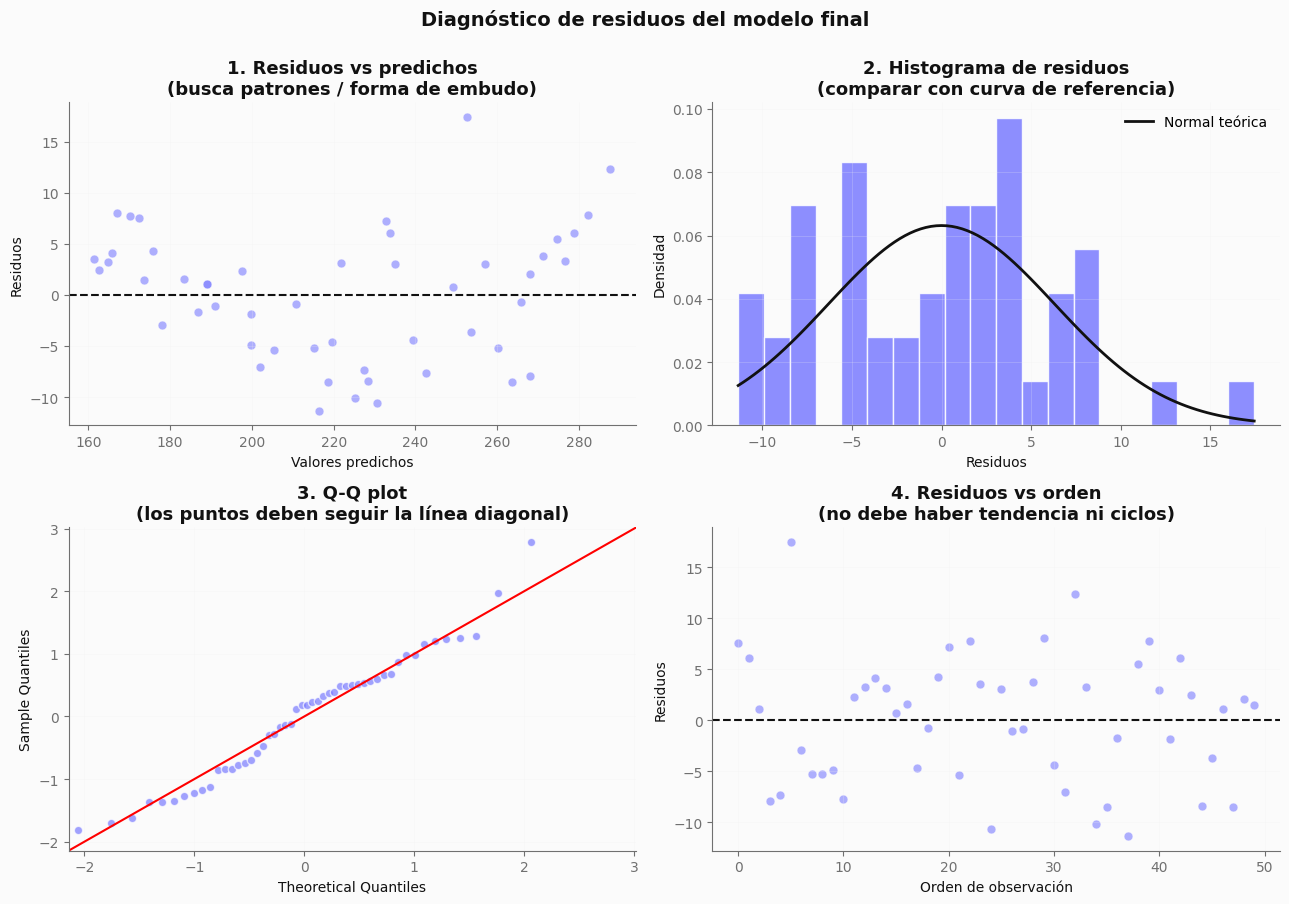

In [18]:
modelo_final = modelo_1
residuos = modelo_final.resid
predichos = modelo_final.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Diagnóstico de residuos del modelo final', fontsize=14, fontweight='bold', color=INK, y=1.00)

# 1. Residuos vs valores predichos (linealidad + homocedasticidad)
axes[0, 0].scatter(predichos, residuos, color=PURPLE, alpha=0.6, s=40, edgecolor='white', linewidth=0.5)
axes[0, 0].axhline(0, color=INK, linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Valores predichos')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('1. Residuos vs predichos\n(busca patrones / forma de embudo)', color=INK)
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma de residuos (normalidad)
axes[0, 1].hist(residuos, bins=20, color=PURPLE, edgecolor='white', alpha=0.85, density=True)
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
                color=INK, linewidth=2, label='Normal teórica')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('2. Histograma de residuos\n(comparar con curva de referencia)', color=INK)
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (normalidad)
sm.qqplot(residuos, line='45', fit=True, ax=axes[1, 0],
          markerfacecolor=PURPLE, markeredgecolor='white', alpha=0.7, markersize=6)
axes[1, 0].set_title('3. Q-Q plot\n(los puntos deben seguir la línea diagonal)', color=INK)
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuos vs orden (independencia)
axes[1, 1].scatter(range(len(residuos)), residuos, color=PURPLE, alpha=0.6, s=40, edgecolor='white', linewidth=0.5)
axes[1, 1].axhline(0, color=INK, linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel('Orden de observación')
axes[1, 1].set_ylabel('Residuos')
axes[1, 1].set_title('4. Residuos vs orden\n(no debe haber tendencia ni ciclos)', color=INK)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Validación con train/test split

In [19]:
X = data[["bmi"]]
y = data["cholesterol"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 40 registros
Test:  10 registros


## 6. Modelo de regresion lineal simple

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

b0 = model.intercept_
b1 = model.coef_[0]

print("Ecuacion del modelo:")
print(f"  Colesterol = {b0:.2f} + {b1:.2f} * BMI")
print()
print("Interpretacion:")
print(f"  - Intercepto: {b0:.2f} (colesterol teorico a BMI = 0)")
print(f"  - Pendiente: {b1:.2f} unidades de colesterol por punto de BMI")

Ecuacion del modelo:
  Colesterol = -74.66 + 10.96 * BMI

Interpretacion:
  - Intercepto: -74.66 (colesterol teorico a BMI = 0)
  - Pendiente: 10.96 unidades de colesterol por punto de BMI


In [21]:
# Entrenamos con sklearn
modelo_ml = LinearRegression()
modelo_ml.fit(X_train, y_train)

# Predicciones
y_pred_train = modelo_ml.predict(X_train)
y_pred_test  = modelo_ml.predict(X_test)

# Métricas
def metricas(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    print(f'{nombre}:')
    print(f'  R²    : {r2:.4f}')
    print(f'  RMSE  : {rmse:.2f}  (raíz del error cuadrático medio, colesterol)')
    print(f'  MAE   : {mae:.2f}  (error absoluto medio, colesterol)')
    print(f'  MAPE  : {mape:.2f}%  (error porcentual medio)')
    return r2, rmse

print('═' * 60)
r2_train, rmse_train = metricas(y_train, y_pred_train, 'TRAIN (datos vistos)')
print()
r2_test,  rmse_test  = metricas(y_test, y_pred_test, 'TEST (datos nuevos)')
print('═' * 60)

# Diagnóstico de overfitting
diff_r2 = r2_train - r2_test
print(f'\nDiferencia R²: {diff_r2:.4f}')
if abs(diff_r2) < 0.05:
    print('No hay overfitting: el modelo generaliza bien.')
elif diff_r2 > 0.05:
    print('Posible overfitting: el modelo va mejor en train que en test.')
else:
    print('Atípico: el modelo va mejor en test (poco común, revisar muestra).')

════════════════════════════════════════════════════════════
TRAIN (datos vistos):
  R²    : 0.9698
  RMSE  : 6.38  (raíz del error cuadrático medio, colesterol)
  MAE   : 5.34  (error absoluto medio, colesterol)
  MAPE  : 2.41%  (error porcentual medio)

TEST (datos nuevos):
  R²    : 0.9814
  RMSE  : 5.82  (raíz del error cuadrático medio, colesterol)
  MAE   : 4.84  (error absoluto medio, colesterol)
  MAPE  : 2.17%  (error porcentual medio)
════════════════════════════════════════════════════════════

Diferencia R²: -0.0116
No hay overfitting: el modelo generaliza bien.


- El modelo presenta un excelente rendimiento predictivo, tanto en train como en test. La similitud entre las métricas de ambos conjuntos indica que ha aprendido la relación entre las variables sin memorizar los datos de entrenamiento, por lo que es capaz de realizar predicciones precisas sobre nuevas observaciones. 
- Un MAPE inferior al 3 % y un R² cercano al 98 % reflejan una elevada capacidad de generalización y un ajuste muy satisfactorio para este conjunto de datos.

In [ ]:
# Visualizamos la calidad de predicción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs predicho
axes[0].scatter(y_test, y_pred_test, color=PURPLE, alpha=0.7, s=60, edgecolor='white', linewidth=0.8, label='Predicciones')
min_val, max_val = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color=INK, linestyle='--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Colesterol real')
axes[0].set_ylabel('Colesterol predicho')
axes[0].set_title(f'Real vs Predicho · R² test = {r2_test:.3f}', color=INK)
axes[0].legend(frameon=False)
axes[0].grid(True, alpha=0.3)

# Errores de predicción
errores_test = y_test - y_pred_test
bias_color = POSITIVE if errores_test.mean() >= 0 else NEGATIVE
axes[1].hist(errores_test, bins=15, color=PURPLE, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color=INK, linestyle='--', linewidth=2)
axes[1].axvline(errores_test.mean(), color=bias_color, linestyle='--', linewidth=2, label=f'Sesgo medio: {errores_test.mean():.2f}')
axes[1].set_xlabel('Error (Real − Predicho) en colesterol')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de errores · MAE = {mean_absolute_error(y_test, y_pred_test):.2f}', color=INK)
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Predicción del colesterol a partir del BMI

def predecir_colesterol(bmi, modelo=modelo_ml, incertidumbre=True):
    """
    Predice el nivel de colesterol de un paciente a partir de su IMC (BMI).

    Parámetros
    ----------
    bmi : float
        Índice de Masa Corporal (BMI).
    modelo : sklearn.linear_model.LinearRegression
        Modelo de regresión entrenado.
    incertidumbre : bool
        Si es True, devuelve un intervalo aproximado del 95 %.

    Devuelve
    --------
    dict con la predicción y, opcionalmente, el intervalo de confianza.
    """

    X_nuevo = pd.DataFrame({
        "bmi": [bmi]
    })

    pred = modelo.predict(X_nuevo)[0]

    resultado = {
        "colesterol_predicho": round(pred, 2)
    }

    if incertidumbre:
        margen = 1.96 * rmse_test
        resultado["intervalo_95"] = (
            round(pred - margen, 2),
            round(pred + margen, 2)
        )

    return resultado


# ============================================================
# EJEMPLOS DE PREDICCIÓN
# ============================================================

print("EJEMPLOS DE PREDICCIÓN")
print("─" * 60)

casos = [
    {"bmi": 21.5, "descripcion": "Paciente con IMC normal"},
    {"bmi": 26.8, "descripcion": "Paciente con sobrepeso"},
    {"bmi": 32.5, "descripcion": "Paciente con obesidad"},
]

for caso in casos:

    pred = predecir_colesterol(caso["bmi"])

    print(f"\n{caso['descripcion']}")
    print(f"  BMI                  : {caso['bmi']:.1f}")
    print(f"  Colesterol estimado  : {pred['colesterol_predicho']:.2f}")
    print(
        f"  Intervalo 95 %       : "
        f"{pred['intervalo_95'][0]:.2f} – {pred['intervalo_95'][1]:.2f}"
    )

EJEMPLOS DE PREDICCIÓN
────────────────────────────────────────────────────────────

Paciente con IMC normal
  BMI                  : 21.5
  Colesterol estimado  : 161.04
  Intervalo 95 %       : 149.63 – 172.44

Paciente con sobrepeso
  BMI                  : 26.8
  Colesterol estimado  : 219.14
  Intervalo 95 %       : 207.73 – 230.54

Paciente con obesidad
  BMI                  : 32.5
  Colesterol estimado  : 281.62
  Intervalo 95 %       : 270.22 – 293.03


## 6. Insights de negocio y recomendaciones

El modelo desarrollado es capaz de predecir el nivel de colesterol con un 97 % de capacidad explicativa (R² = 0.973) utilizando únicamente una variable: el Índice de Masa Corporal (BMI).

- ¿Qué ha aprendido el modelo?
Por cada unidad adicional de BMI, el colesterol aumenta, en promedio, 10.98 unidades.

El BMI es un predictor altamente significativo (p < 0.001), lo que confirma una relación lineal positiva entre el índice de masa corporal y el colesterol.
- ¿Por qué se eligió este modelo?

Aunque los modelos con más variables alcanzaban un R² ligeramente superior (≈99 %), todos presentaban problemas graves de multicolinealidad, lo que dificultaba interpretar el efecto individual de cada variable y reducía la estabilidad de los coeficientes.

El Modelo 1 ofrece el mejor equilibrio entre:

- Simplicidad, al utilizar una única variable predictora.
- Interpretabilidad, ya que el efecto del BMI es directo y fácil de explicar.
- Robustez, al no presentar problemas de multicolinealidad (VIF = 1).